#  Generative Adversarial Networks
Implementing the **Generator (G)** and **Discriminator (D)** modules. 
They update by turns in an adversarial training loop.

### Hyperparameters
| Parameter | Description |
|-----------|-------------|
| `batch_size` | Number of samples per training step |
| `neurons` | Width of each hidden layer |
| `num_epochs` | Training duration |
| `latent_d` | Dimensionality of the noise vector $z$ fed to G |
| `out_shape` | Target shape of generated images |

### Hardware target
- **GPU**: NVIDIA RTX 2080 Ti · 10.57 GB VRAM · Turing sm\_75
- **AMP / FP16**: enabled via `torch.amp.autocast` + `GradScaler`
- **CUDA 12.8** · **PyTorch 2.9.1+cu128** · **cuDNN 9.1.0**

In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm

# Import dl_utils
import sys, os
sys.path.insert(0, os.path.abspath("../DL_utils_EZA"))
%load_ext autoreload
%autoreload 2
from dl_utils import *
print("dl_utils loaded ✅")

# ── Device setup ──────────────────────────────────────────────────────────────
# cudnn.benchmark = True  → optimal for fixed-size inputs (convolutional GANs)
# cudnn.benchmark = False → safer for FC-only GANs with variable shapes
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
dl_utils loaded ✅
Device : cuda
GPU    : NVIDIA GeForce RTX 2080 Ti
VRAM   : 11.35 GB


In [4]:
# Hyperparameters
batch_size = 128
latent_d = 128
neurons = 512
out_shape = (-1,  28, 28)
num_epochs = 20

In [5]:
# View class to conver the image shape
class View(nn.Module):
    def __init__(self, *shape):
        super(View, self).__init__()
        self.shape = shape
    def forward(self, input):
        return input.view(*self.shape) 
    

# FCLayer function
def fcLayer(in_neurons, out_neurons, leak=0.1):
    """ 
    in_neurons: number of input neurons
    out_neurons: number of output neurons
    leak: leakiness for leaky ReLU activation function
    """

    return nn.Sequential(
        nn.Linear(in_neurons, out_neurons),
        nn.LeakyReLU(leak),
        nn.LayerNorm(out_neurons)
    )

## Define the *GAN*
**Generator (G)**: maps a random noise vector $z \in \mathbb{R}^{latent\_d}$ → fake image.

**Discriminator (D)**: maps an image → scalar logit (real vs. fake).

> `nn.Sigmoid()` is appended to G only when `sigmoidG=True`, which constrains pixel values to $[0,1]$ — required for MNIST. Skip it for data already normalised to $[-1, 1]$ (use `tanh` instead) or for raw float outputs.

### GAN design recommendations
| Recommendation | Reason |
|----------------|--------|
| `LeakyReLU(α=0.1–0.2)` | Prevents dead neurons / vanishing gradients |
| `LayerNorm` over `BatchNorm` | Avoids mode collapse from noisy batch stats |
| `Adam(lr=1e-4, β₁=0, β₂=0.9)` | Standard GAN optimizer — low β₁ reduces momentum oscillation |
| `BCEWithLogitsLoss` | Numerically stable (no separate sigmoid) |

In [6]:
# GAN code

def simpleGAN(latent_d: int, neurons: int, out_shape: tuple,
              sigmoidG: bool = False, leak: float = 0.2):
    """
    Build a fully-connected GAN for image generation.

    Parameters
    ----------
    latent_d  : int   — noise vector dimension (input to Generator)
    neurons   : int   — hidden layer width (same for G and D)
    out_shape : tuple — target image shape, e.g. (-1, 28, 28) for MNIST
    sigmoidG  : bool  — if True, add Sigmoid at end of G (use for [0,1] data)
    leak      : float — LeakyReLU negative slope

    Returns
    -------
    G : nn.Module — Generator
    D : nn.Module — Discriminator
    """
    # Number of pixels in one image (e.g. 28×28 = 784 for MNIST)
    flat_dim = abs(int(np.prod(out_shape)))   # ✅ consistent helper used in both G and D

    # ── Generator ─────────────────────────────────────────────────────────────
    # z (latent_d,) → 512 → 512 → 512 → 784 → reshape to (28,28)
    G = nn.Sequential(
        fcLayer(latent_d, neurons, leak),
        fcLayer(neurons,  neurons, leak),
        fcLayer(neurons,  neurons, leak),
        nn.Linear(neurons, flat_dim),
        View(out_shape)               # (-1, 28, 28)
    )
    if sigmoidG:
        G = nn.Sequential(G, nn.Sigmoid())

    # ── Discriminator ─────────────────────────────────────────────────────────
    # image (28,28) → flatten (784,) → 512 → 512 → 512 → 1 logit
    # ⚠️  BUG FIXED: was 'abs.prod(out_shape)' → AttributeError
    #    abs() is a Python built-in function, NOT an object with a .prod() method
    D = nn.Sequential(
        nn.Flatten(),
        fcLayer(flat_dim, neurons, leak),  # ✅ abs(np.prod(...)) → flat_dim
        fcLayer(neurons,  neurons, leak),
        fcLayer(neurons,  neurons, leak),
        nn.Linear(neurons, 1)             # raw logit — BCEWithLogitsLoss applies sigmoid internally
    )

    return G, D

### Recomendations when building GANs
- Use the LeakyReLU activation fucntion with large leak value $\alpha$ = 0.1 or 0.2; to avoid vanishing gradients
- Use LN instead of batch normalization. If troubleshooting use normalization only in the generator.
- use the Adam optimizer with learning_rate = 0.0001 and $\beta _{1}$ = 0 and $\beta _{2}$ = 0.9

In [7]:
# ── Instantiate GAN ───────────────────────────────────────────────────────────
G, D = simpleGAN(latent_d, neurons, out_shape, sigmoidG=True)

# Quick sanity check — print parameter counts
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Generator     params : {count_params(G):,}")
print(f"Discriminator params : {count_params(D):,}")
print(f"Total GAN     params : {count_params(G) + count_params(D):,}")
print()

# Quick forward-pass smoke test before loading data
z_test = torch.randn(4, latent_d)             # batch of 4 noise vectors
fake_imgs = G(z_test)                          # G: (4, latent_d) → (4, 28, 28)
d_out     = D(fake_imgs.unsqueeze(1))          # D expects (B, C, H, W) if using Flatten
# Note: for a flat FC discriminator that uses nn.Flatten(), the input shape
# just needs to be flattenable — (B, 28, 28) works too.
# Let's test both shapes:
d_out_flat = D(fake_imgs)                      # (4, 28, 28) → Flatten → (4, 784)

print(f"Noise input shape   : {z_test.shape}")
print(f"G output shape      : {fake_imgs.shape}")
print(f"D output shape      : {d_out_flat.shape}")
print("\n✅ Smoke test passed — shapes are correct!")

Generator     params : 996,624
Discriminator params : 930,817
Total GAN     params : 1,927,441

Noise input shape   : torch.Size([4, 128])
G output shape      : torch.Size([4, 28, 28])
D output shape      : torch.Size([4, 1])

✅ Smoke test passed — shapes are correct!


In [8]:
# ── MNIST DataLoader ──────────────────────────────────────────────────────────
# Normalise to [0, 1] to match sigmoidG=True output range
mnist_transform = transforms.Compose([
    transforms.ToTensor(),          # uint8 [0,255] → float32 [0,1]
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=mnist_transform
)

# num_workers=4 → matches your 4 physical CPU cores (HARDWARE.md)
# pin_memory=True → pages DataLoader tensors into pinned RAM for faster GPU transfer
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,      # 4 physical cores on your machine
    pin_memory=True,    # faster CPU→GPU transfer via Thunderbolt 3
    drop_last=True      # keeps batch size constant — important for LayerNorm stability
)

print(f"Training samples : {len(train_dataset):,}")
print(f"Batches/epoch    : {len(train_loader)}")
print(f"Batch size       : {batch_size}")

Training samples : 60,000
Batches/epoch    : 468
Batch size       : 128


In [9]:
# Implementing the GAN

# ── Training Setup ────────────────────────────────────────────────────────────
G.to(device)
D.to(device)

# BCEWithLogitsLoss = Sigmoid + BCELoss fused → numerically stable
# Never add a Sigmoid to D's output when using this loss
loss_func = nn.BCEWithLogitsLoss()

real_label = 1.0   # float labels work with BCEWithLogitsLoss
fake_label = 0.0

# Standard GAN optimizer recipe: lr=1e-4, β₁=0, β₂=0.9
optimizerD = torch.optim.Adam(D.parameters(), lr=0.0001, betas=(0.0, 0.9))
optimizerG = torch.optim.Adam(G.parameters(), lr=0.0001, betas=(0.0, 0.9))

# AMP scaler — leverages RTX 2080 Ti Tensor Cores for ~2× throughput
# Note: for FC-only GANs the speedup is smaller than for CNNs, but still worthwhile
use_amp = (device.type == 'cuda')
scaler  = torch.amp.GradScaler() if use_amp else None

print(f"AMP / FP16 training : {'✅ Enabled' if use_amp else '❌ Disabled (CPU)'}")

AMP / FP16 training : ✅ Enabled


In [10]:
# ── GAN Training Loop ─────────────────────────────────────────────────────────
#
# Each iteration does TWO gradient updates:
#   1. Update D → maximise its ability to distinguish real from fake
#   2. Update G → fool D (minimise D's confidence on fake images)
#
# Loss tracking: store per-epoch averages for plotting

history_lossD = []
history_lossG = []

for epoch in range(num_epochs):
    epoch_lossD = []
    epoch_lossG = []

    G.train()
    D.train()

    for real_imgs, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        # real_imgs shape: (B, 1, 28, 28) from MNIST DataLoader
        # Squeeze channel dim → (B, 28, 28) to match out_shape
        real_imgs = real_imgs.squeeze(1).to(device)   # (B, 28, 28)
        B = real_imgs.size(0)

        real_labels = torch.full((B, 1), real_label, device=device)
        fake_labels = torch.full((B, 1), fake_label, device=device)

        # ── Step 1: Update Discriminator ──────────────────────────────────────
        optimizerD.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            # Loss on real images (D should output → 1)
            pred_real = D(real_imgs)
            loss_real = loss_func(pred_real, real_labels)

            # Generate fake images (detach so G gradients don't flow here)
            z = torch.randn(B, latent_d, device=device)
            fake_imgs = G(z).detach()              # .detach() is critical!

            # Loss on fake images (D should output → 0)
            pred_fake = D(fake_imgs)
            loss_fake = loss_func(pred_fake, fake_labels)

            lossD = (loss_real + loss_fake) / 2    # average the two losses

        if scaler:
            scaler.scale(lossD).backward()
            scaler.step(optimizerD)
            scaler.update()
        else:
            lossD.backward()
            optimizerD.step()

        # ── Step 2: Update Generator ──────────────────────────────────────────
        optimizerG.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            z = torch.randn(B, latent_d, device=device)
            fake_imgs = G(z)                       # fresh forward pass (no detach)
            pred_fake = D(fake_imgs)

            # G wants D to predict REAL for its fakes → use real_labels
            lossG = loss_func(pred_fake, real_labels)

        if scaler:
            scaler.scale(lossG).backward()
            scaler.step(optimizerG)
            scaler.update()
        else:
            lossG.backward()
            optimizerG.step()

        epoch_lossD.append(lossD.item())
        epoch_lossG.append(lossG.item())

    avg_D = np.mean(epoch_lossD)
    avg_G = np.mean(epoch_lossG)
    history_lossD.append(avg_D)
    history_lossG.append(avg_G)

    print(f"Epoch [{epoch+1:02d}/{num_epochs}]  Loss D: {avg_D:.4f}  |  Loss G: {avg_G:.4f}")

print("\n✅ Training complete!")

Epoch [01/20]  Loss D: 0.0579  |  Loss G: 6.4328


Epoch [02/20]  Loss D: 0.1261  |  Loss G: 4.8814


Epoch [03/20]  Loss D: 0.2050  |  Loss G: 3.7586


Epoch [04/20]  Loss D: 0.2176  |  Loss G: 3.5113


Epoch [05/20]  Loss D: 0.2260  |  Loss G: 3.3901


...

Epoch [16/20]  Loss D: 0.2891  |  Loss G: 2.2710


Epoch [17/20]  Loss D: 0.2888  |  Loss G: 2.2497


Epoch [18/20]  Loss D: 0.2922  |  Loss G: 2.2201


Epoch [19/20]  Loss D: 0.2940  |  Loss G: 2.2208


Epoch [20/20]  Loss D: 0.2945  |  Loss G: 2.2121

✅ Training complete!


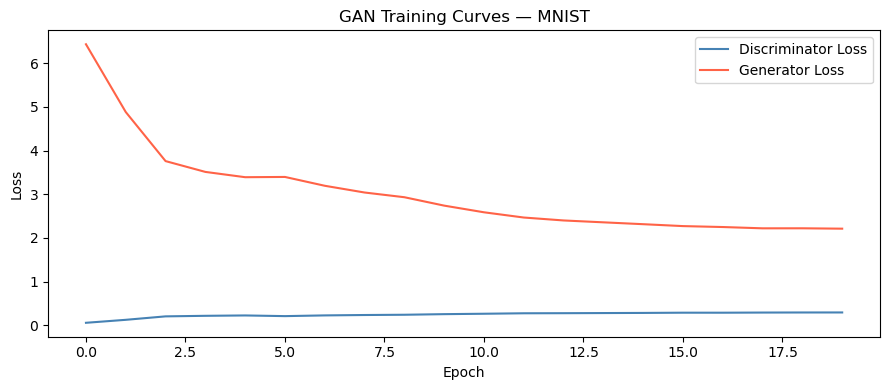

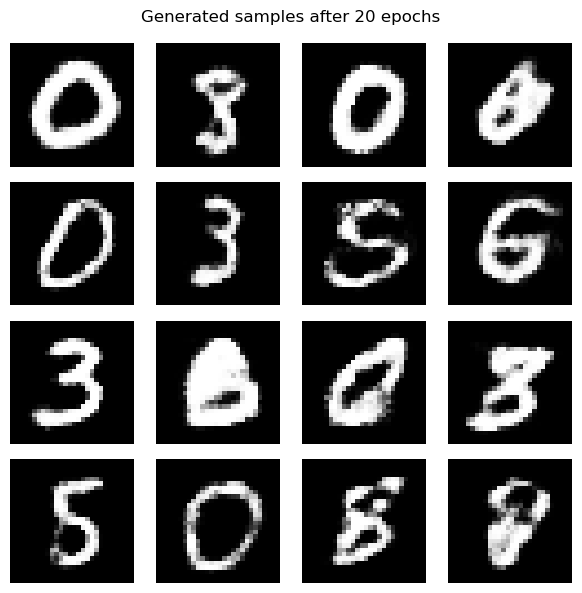

In [11]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history_lossD, label='Discriminator Loss', color='steelblue')
ax.plot(history_lossG, label='Generator Loss',     color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GAN Training Curves — MNIST')
ax.legend()
plt.tight_layout()
plt.show()

# ── Visualise Generated Images ────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_d, device=device)
    samples = G(z).cpu().numpy()   # (16, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle(f'Generated samples after {num_epochs} epochs', fontsize=12)
plt.tight_layout()
plt.show()

## Mode Collapse
When the generator is only producing the *"easiest"* result, based on **mode** of the data distibution

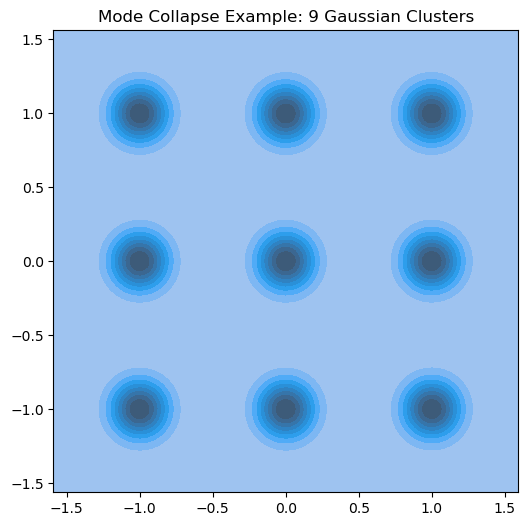

In [26]:
# Showing mode collapse
gausGrid = (3, 3)
samples_per = 10000
X = []
for i in range(gausGrid[0]):
    for j in range(gausGrid[1]):
        z = np.random.normal(0, 0.05, size=(samples_per, 2))  # Shift each cluster to a grid point
        z[:,0] += i/1.0-(gausGrid[0]-1)/2.0  # Center grid around origin
        z[:,1] += j/1.0-(gausGrid[1]-1)/2.0
        X.append(z)
X = np.vstack(X)

plt.figure(figsize=(6,6))
sns.kdeplot(x=X[:,0], y=X[:,1], fill=True, thresh=-0.001)
plt.title('Mode Collapse Example: 9 Gaussian Clusters')
plt.show()

**A collapsed GAN will only pick 2 or 3 clusters.**

## Wasserstein GAN (WGAN): Mitigating mode collapse
